# Adiabatic reactor for an 5 species air mixture

Adapted from https://github.com/mutationpp/Mutationpp/blob/master/examples/python/Air11_adiabatic_reactor.md.

In this notebook, we will use M++ python package to compute an adiabatic reactor for an air mixture composed by 5 species such that,
$$
\mathcal{S} = [N, O, NO, N_2, O_2].
$$

For this case, the species continuity equation reduces to an ODE and the mixture energy and volume are constant,

$$
\partial_t \rho_i = \dot{\omega_i} \quad \forall i \in \mathcal{S}, \\
\rho e(\rho_i, T) = \text{const}.
$$

The ODE is integrated by a first order Euler explicit method. 

The mixture energy is initialized at $T_{\text{init}}$ = 15000 K and P = 10000 Pa, and the initial composition is obtained at the equilibrium conditions of $T_{\text{eq}}$ = 300 K and P = 10000 Pa.

*Run the following cell to initialize the necessary packages*

In [31]:
# Import desired packages
import mutationpp as mpp
import numpy as np
import matplotlib.pyplot as plt
from labellines import labelLines
from cycler import cycler

In this cell, we define some parameters for beautiful plotting.

In [32]:
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 18

plt.rc('axes', titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
cc = cycler('linestyle', ['-', '--', ':', '-.', '-']) * cycler('color', ['r', 'g', 'b', 'm', 'k'])
plt.rc('axes', prop_cycle=cc)

plt.rc('text', usetex=True)
plt.rc('font', family='Helvetica')

## Initiallizing the mixture from mutation++

The magic starts in the following cells. 

Before initializing the mixture, we need to set-up the desired options for our adiabatic conditions.
The first step is to specify the mixture name, which is the **air_11** mixture, and the thermal database we want to use (**NASA-9**).
Afterward, we specify the state model to be used on our reactor. In this case, we are interested in a one-temperature chemical non-equilibrium model. 
Other models can be used, such as **ChemNonEqTTv** for a two-temperature model and **EquilTP** for a thermo-chemical equilibrium model.

We can print the species within our mixture by using the **getSpeciesDescriptor()** method.

In [33]:
opts = mpp.MixtureOptions("air_5")
opts.setThermodynamicDatabase("NASA-9")
opts.setStateModel("ChemNonEq1T")
print("Mixture species:", opts.getSpeciesDescriptor())

Mixture species: N O NO N2 O2


After, we initialize our mixture based on the options chosen above.

Note, that one could initilize the mixture directly using the mixture name such that,

```python
     mix = mpp.Mixture("air_5")
```

The options above would need to be specified directly in the mixture file **air_5.xml**.

In [34]:
mix = mpp.Mixture(opts)
ns = mix.nSpecies()

We define the initial conditions of our mixture at $T_{\text{eq}}$ = 300 K and P = 10000 Pa using the method equilibrate.
The partial densities are obtained with the method mix.densities().

In [35]:
T = 300
P = 10000
mix.equilibrate(T,P)
rhoi_eq = mix.densities()

Later, we set the state using the intial composition and temperature $T_{\text{init}}$ = 15000.


*Note that one could set state using different options such that:*
  * Sets the current state of the mixture.  Variable sets can be the following:
     *   0: conserved variables (species densities, total energy density)
     *   1: primitive set 1 (species densities, mixture temperature)

In [36]:
Tinit = 15000
mix.setState(rhoi_eq,Tinit,1)
total_energy = mix.mixtureEnergyMass()*mix.density()
print("Etot :", total_energy)


Etot : 2075163.5378491173


We now define the initial and finaly conditions :

In [37]:
time = 0.
time_final = 1e-7
dt = 1.e-9
rhoi = rhoi_eq

y0 = np.divide(rhoi_eq,mix.density())
x0 = mix.convert_y_to_x(y0)

print("Mixture species:", opts.getSpeciesDescriptor())
print("Mass fractions :", y0)
print("T [K]:", mix.T(),", P [Pa]:", mix.P())
print("rho [kg/m3]:", mix.density(),", Cp [J/kg/K]:", mix.mixtureFrozenCpMass())

temperature = np.array(mix.T())
pressure = np.array(mix.P())
density = np.array(mix.density())
mass_fractions = np.array([y0])
mole_fractions =  np.array([x0])
time_reaction = np.array(time)
Cps = np.array(mix.mixtureFrozenCpMass())

Mixture species: N O NO N2 O2
Mass fractions : [6.95522388e-80 3.79056672e-41 2.40811771e-16 7.67082489e-01
 2.32917511e-01]
T [K]: 15000.0 , P [Pa]: 500000.0
rho [kg/m3]: 0.11566313067881753 , Cp [J/kg/K]: 2039.4103186361015


## ODE integration 

After everything is set, we can start integrating our ODE.

In [38]:
while (time < time_final):
   dt = min(dt * 1.0002, 1.e-10)
   
   wdot = mix.netProductionRates()
   rhoi += wdot*dt
   time += dt

   mix.setState(rhoi,total_energy,0)

   y = mix.Y()
   x = mix.convert_y_to_x(np.array(y))
   mass_fractions = np.vstack((mass_fractions,[y]))
   mole_fractions =  np.vstack((mole_fractions,[x]))
   temperature = np.vstack((temperature,mix.T()))
   pressure = np.vstack((pressure,mix.P()))
   density = np.vstack((density,mix.density()))
   time_reaction  = np.vstack((time_reaction,time))
   Cps = np.vstack((Cps,mix.mixtureFrozenCpMass()))

## Plotting the solution

Finally, we can plot the evolution of the species mole fraction and the temperature relaxation in time

[Text(1.701699999999967e-08, 0.17970000856529475, 'N'),
 Text(3.3533499999999345e-08, 0.2877603819232184, 'O'),
 Text(5.004999999999902e-08, 0.013075461570099527, 'NO'),
 Text(6.656649999999869e-08, 0.41249481355958445, 'N2'),
 Text(8.308299999999838e-08, 0.0003197743737958552, 'O2')]

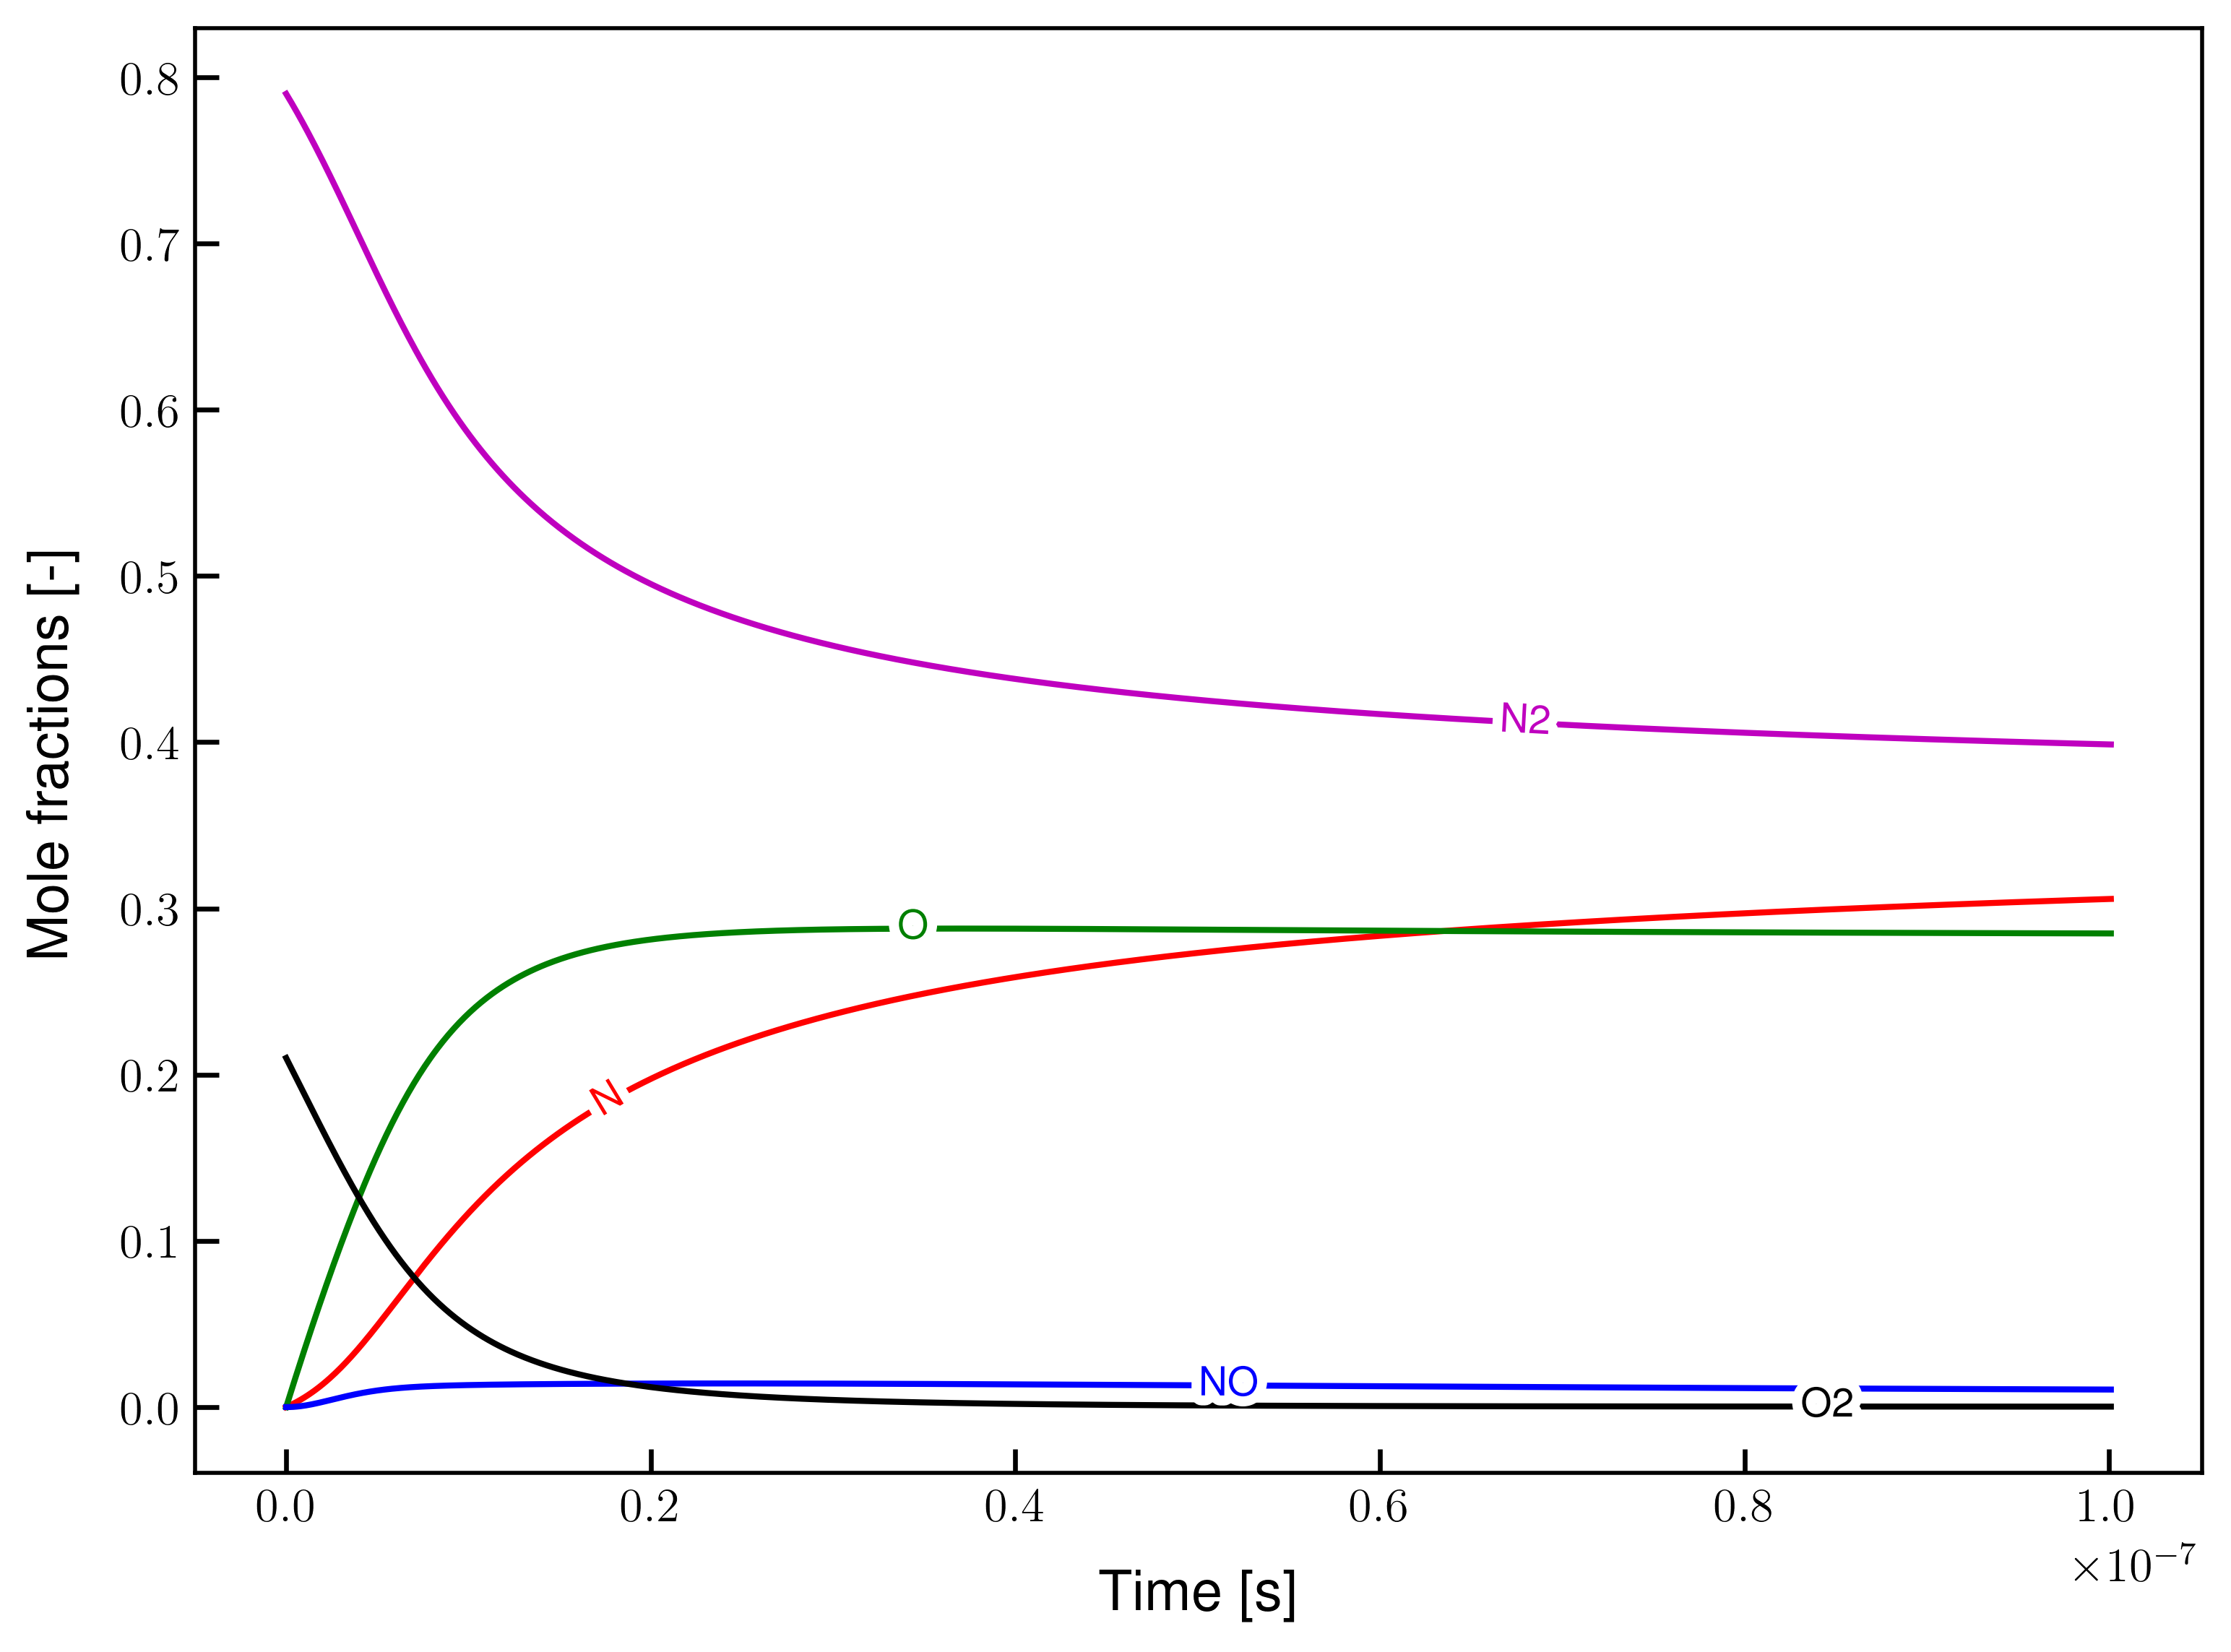

In [39]:
plt.figure()
for i in range(ns):
    plt.plot(time_reaction,mole_fractions[:,i],label=mix.speciesName(i))
plt.ylabel('Mole fractions [-]')
plt.xlabel('Time [s]')
labelLines(plt.gca().get_lines(), align=True, fontsize=10, ha='left')

Text(0.5, 0, 'Time [s]')

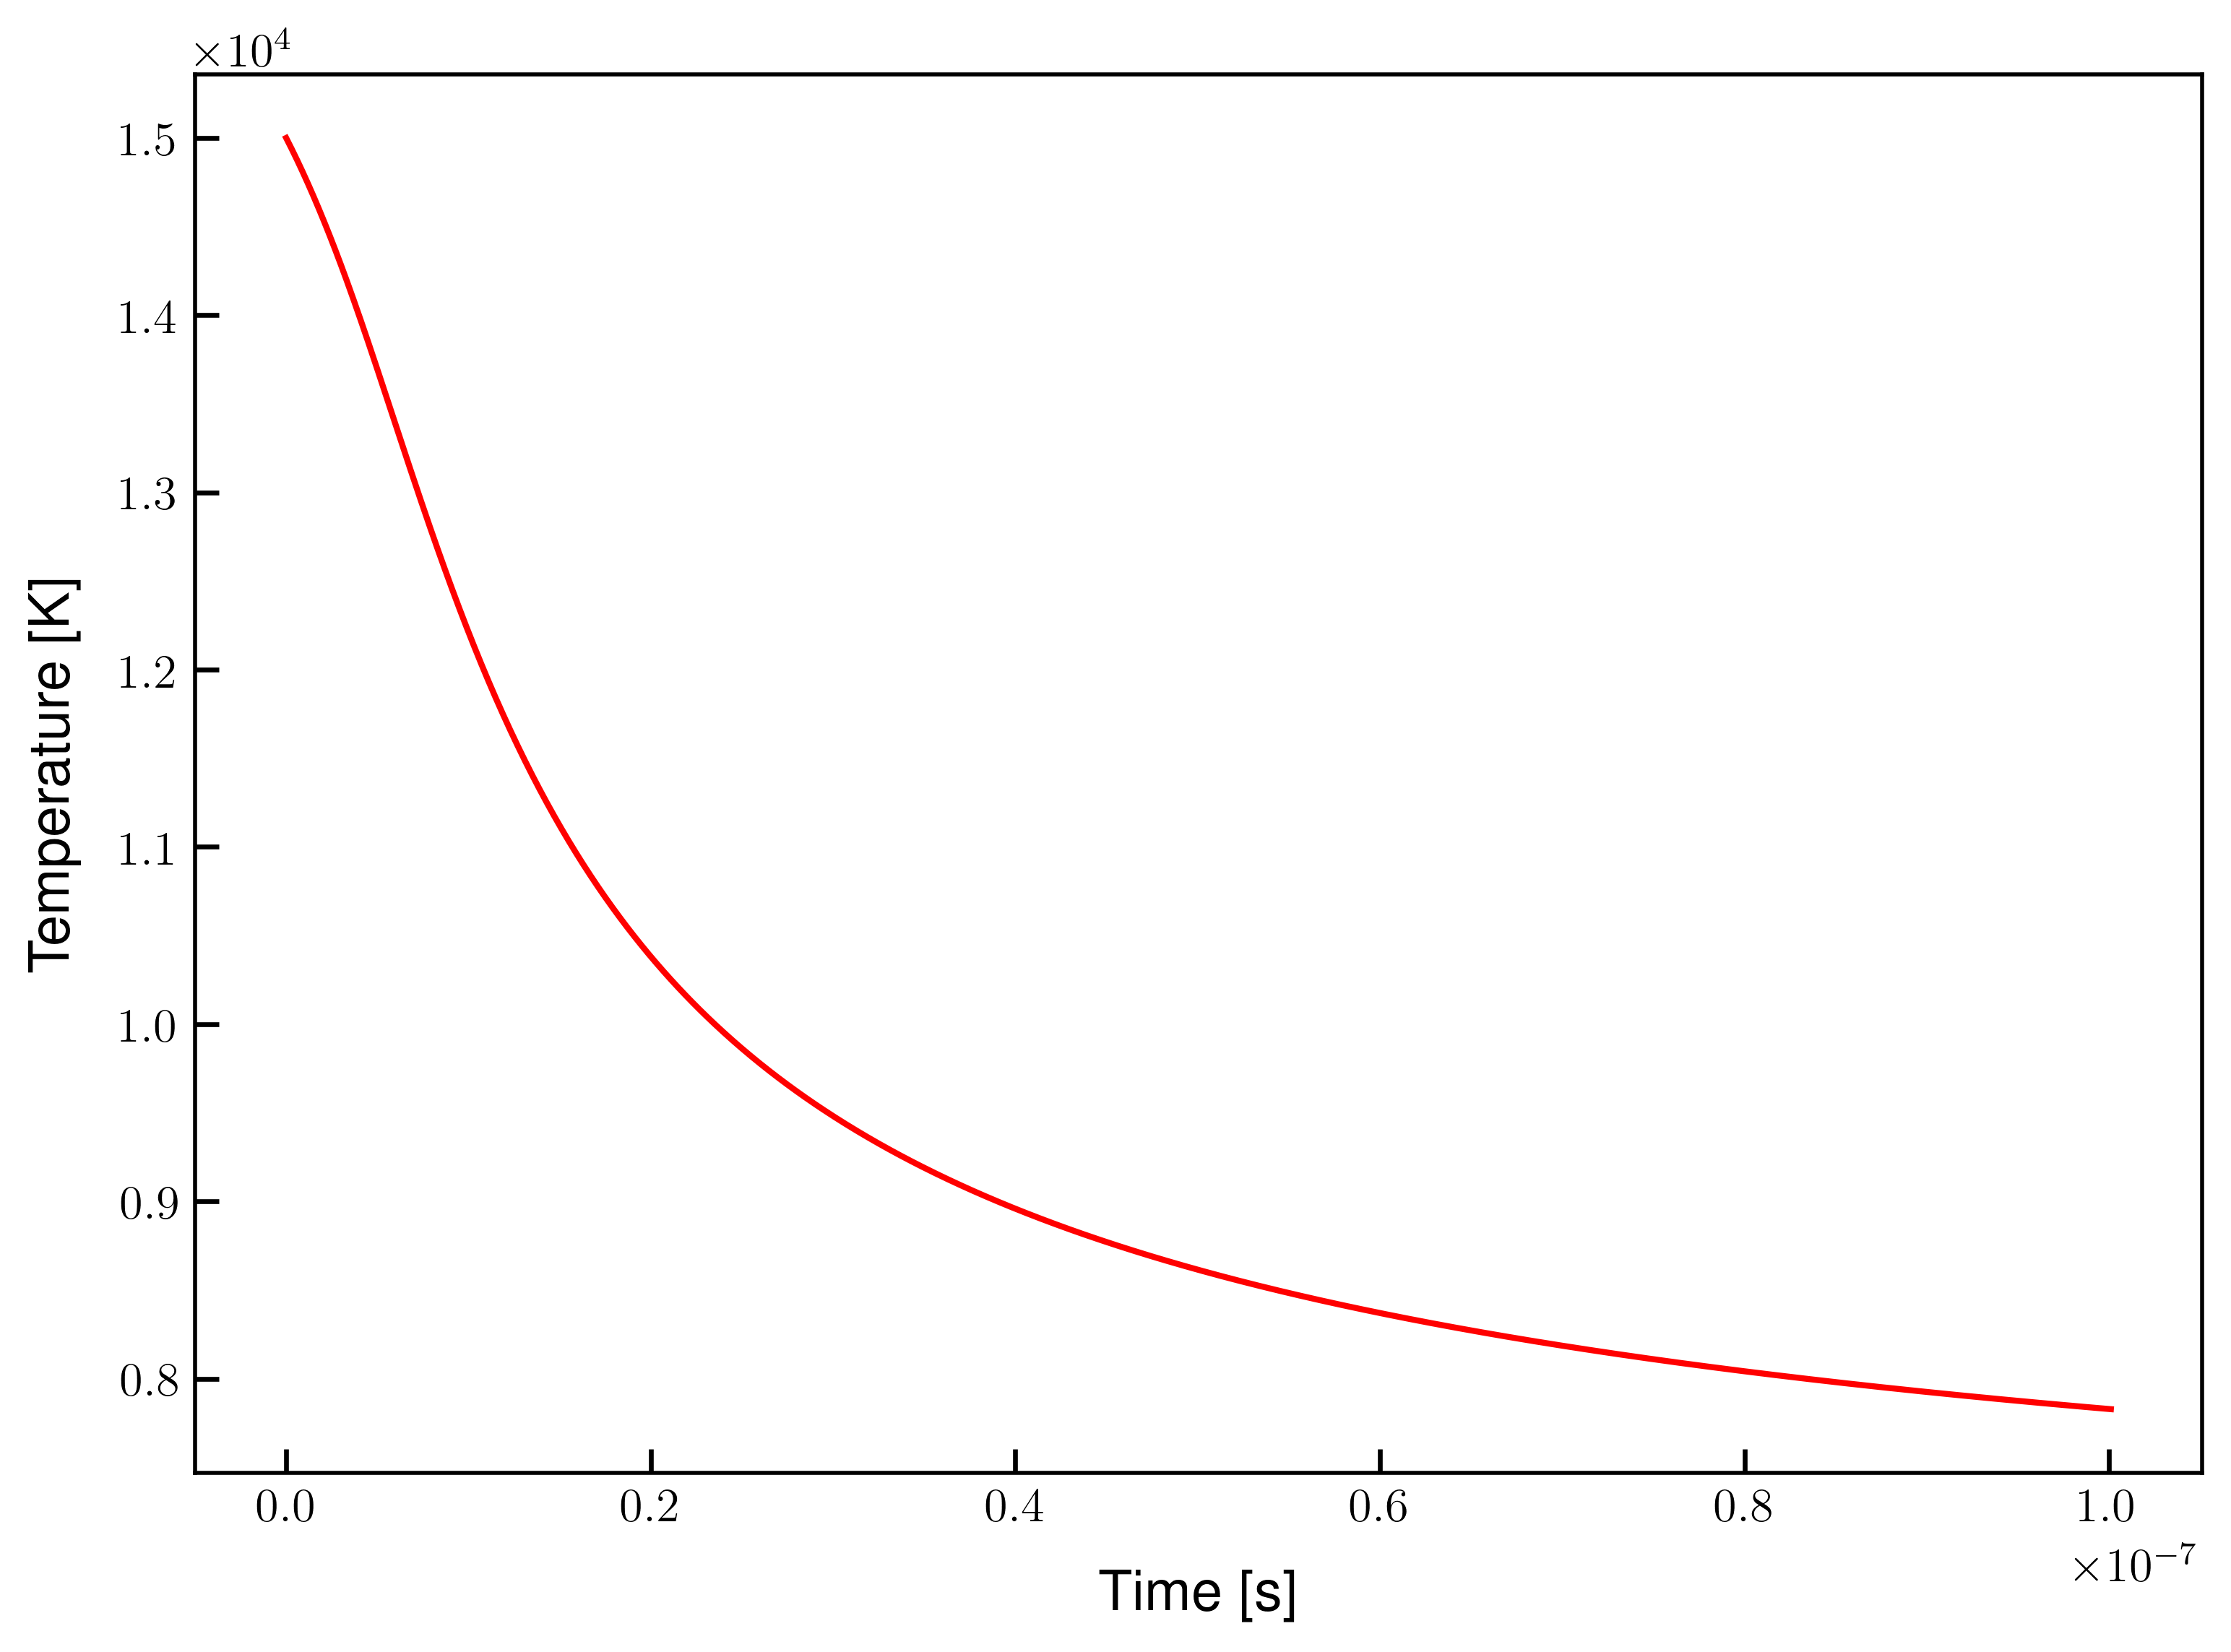

In [40]:
plt.figure()
plt.plot(time_reaction,temperature)
plt.ylabel('Temperature [K]')
plt.xlabel('Time [s]')

Text(0.5, 0, 'Time [s]')

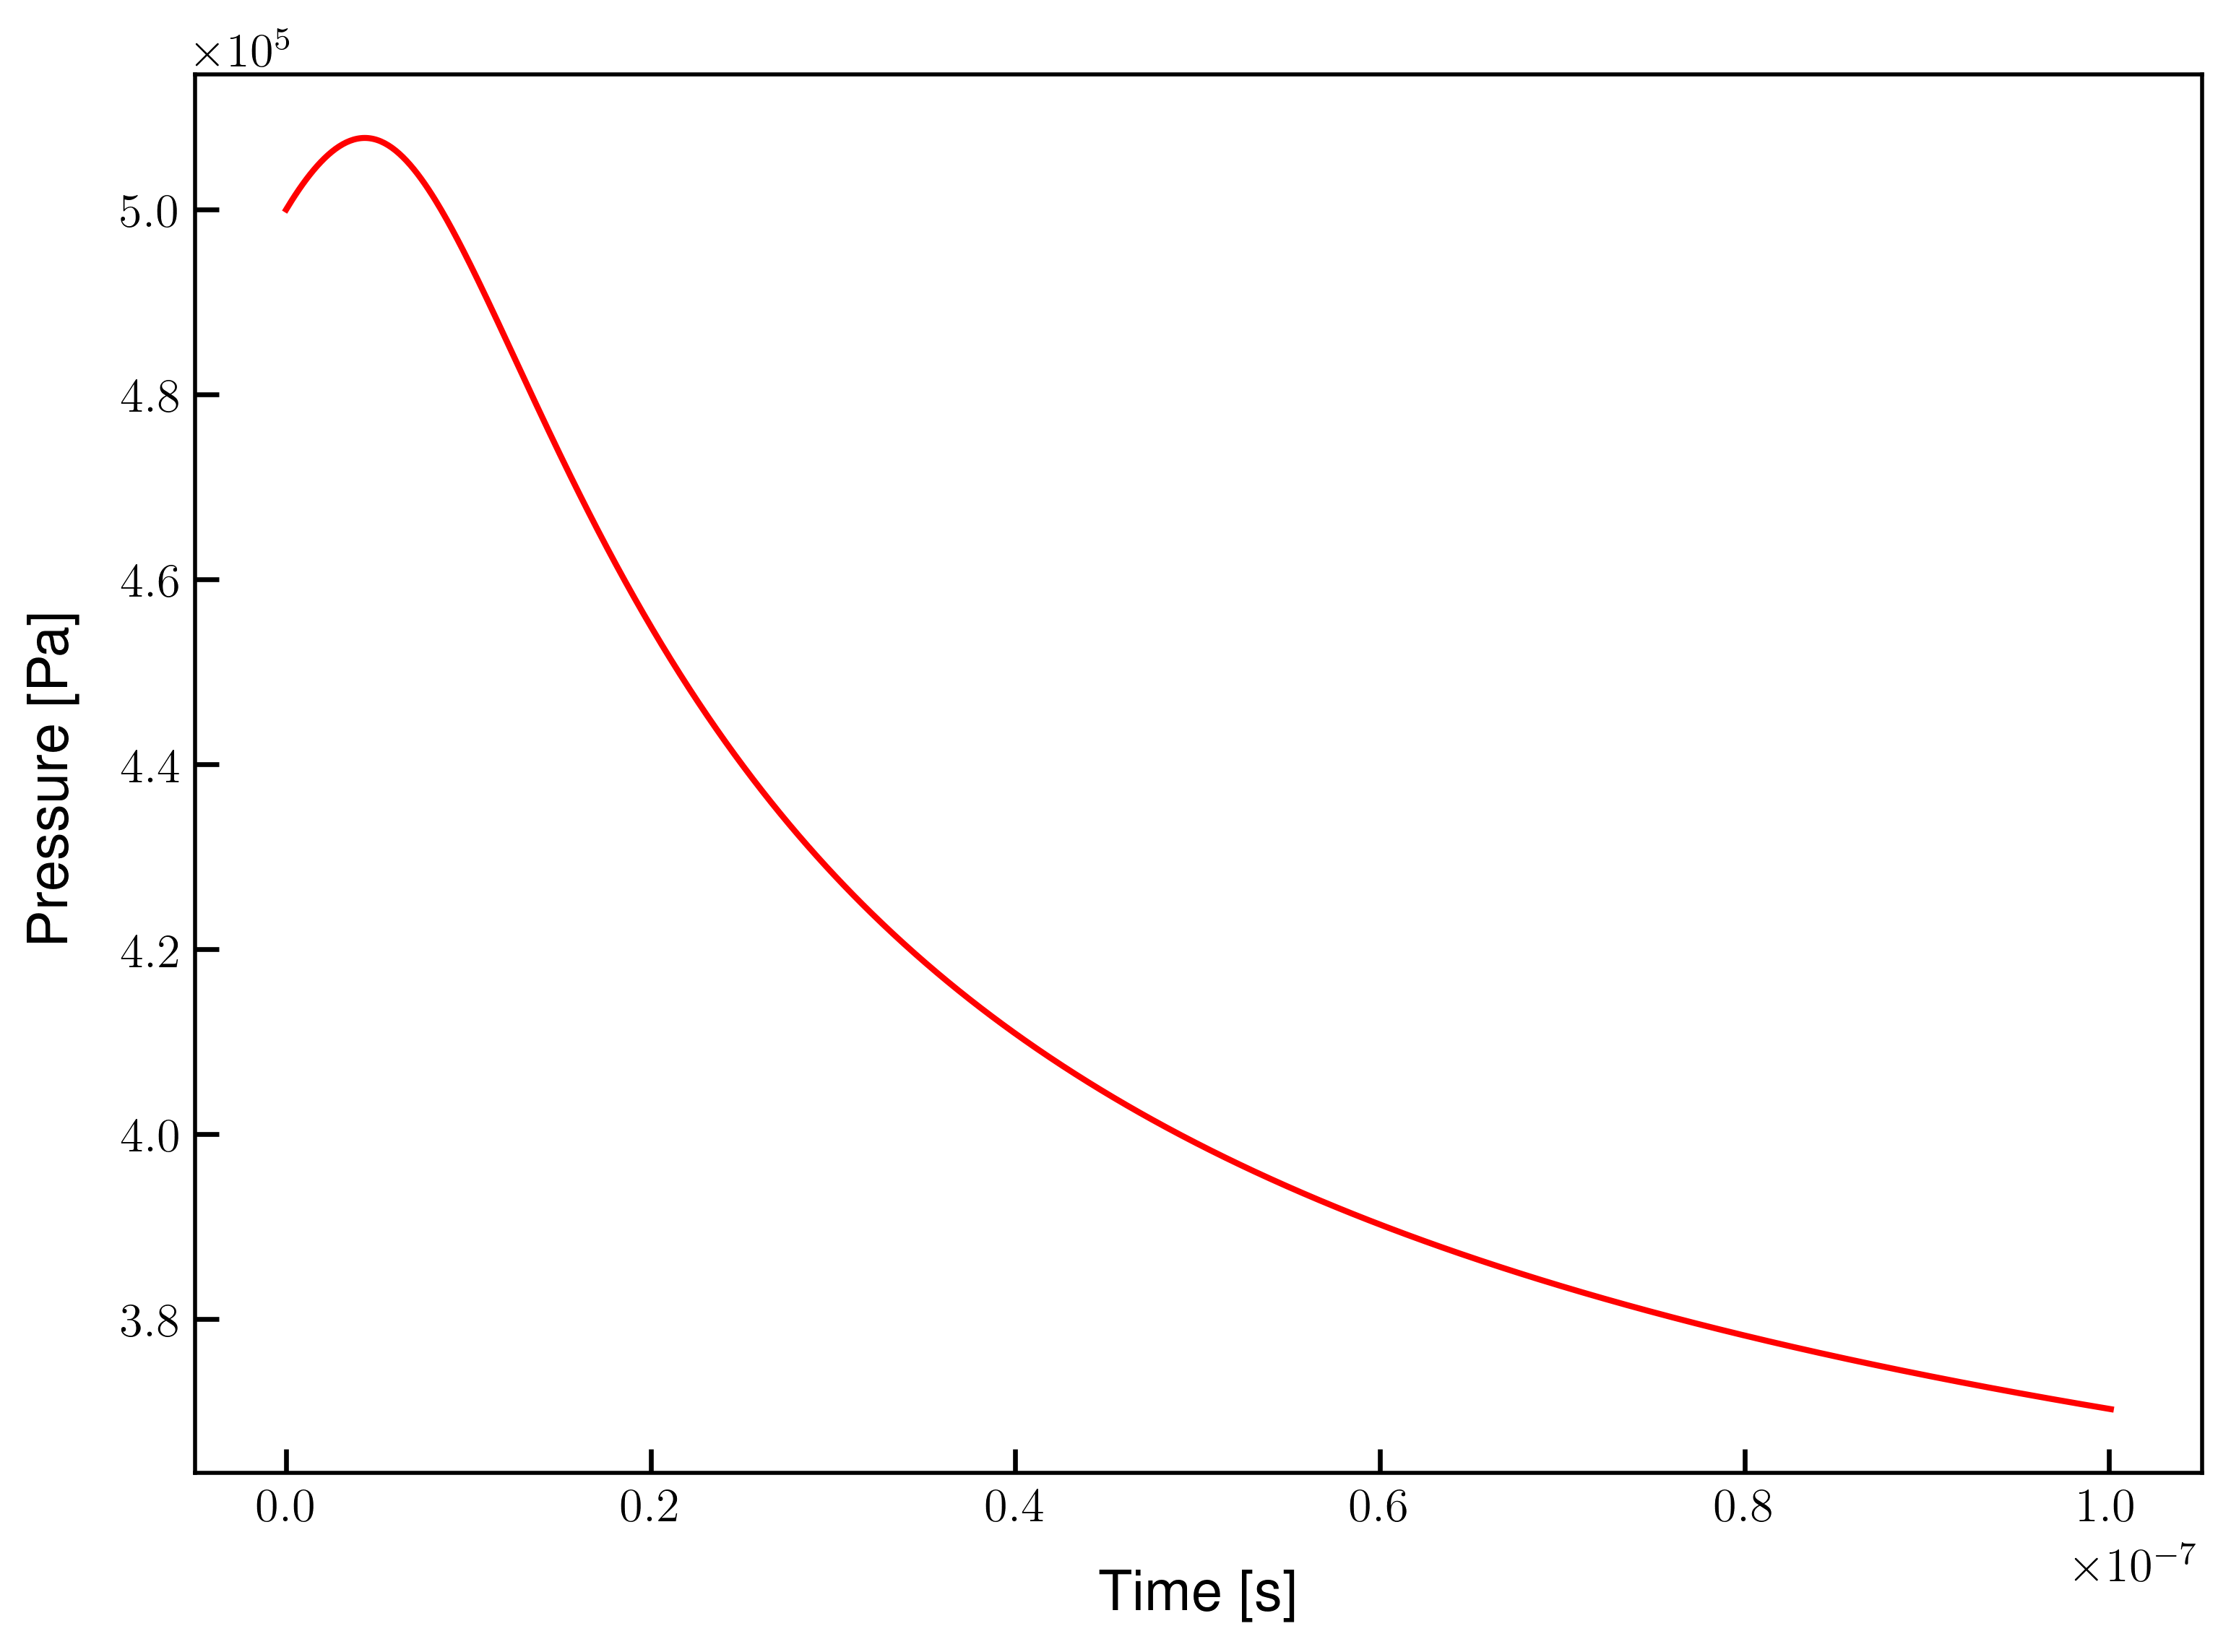

In [41]:
plt.figure()
plt.plot(time_reaction,pressure)
plt.ylabel('Pressure [Pa]')
plt.xlabel('Time [s]')

Text(0.5, 0, 'Time [s]')

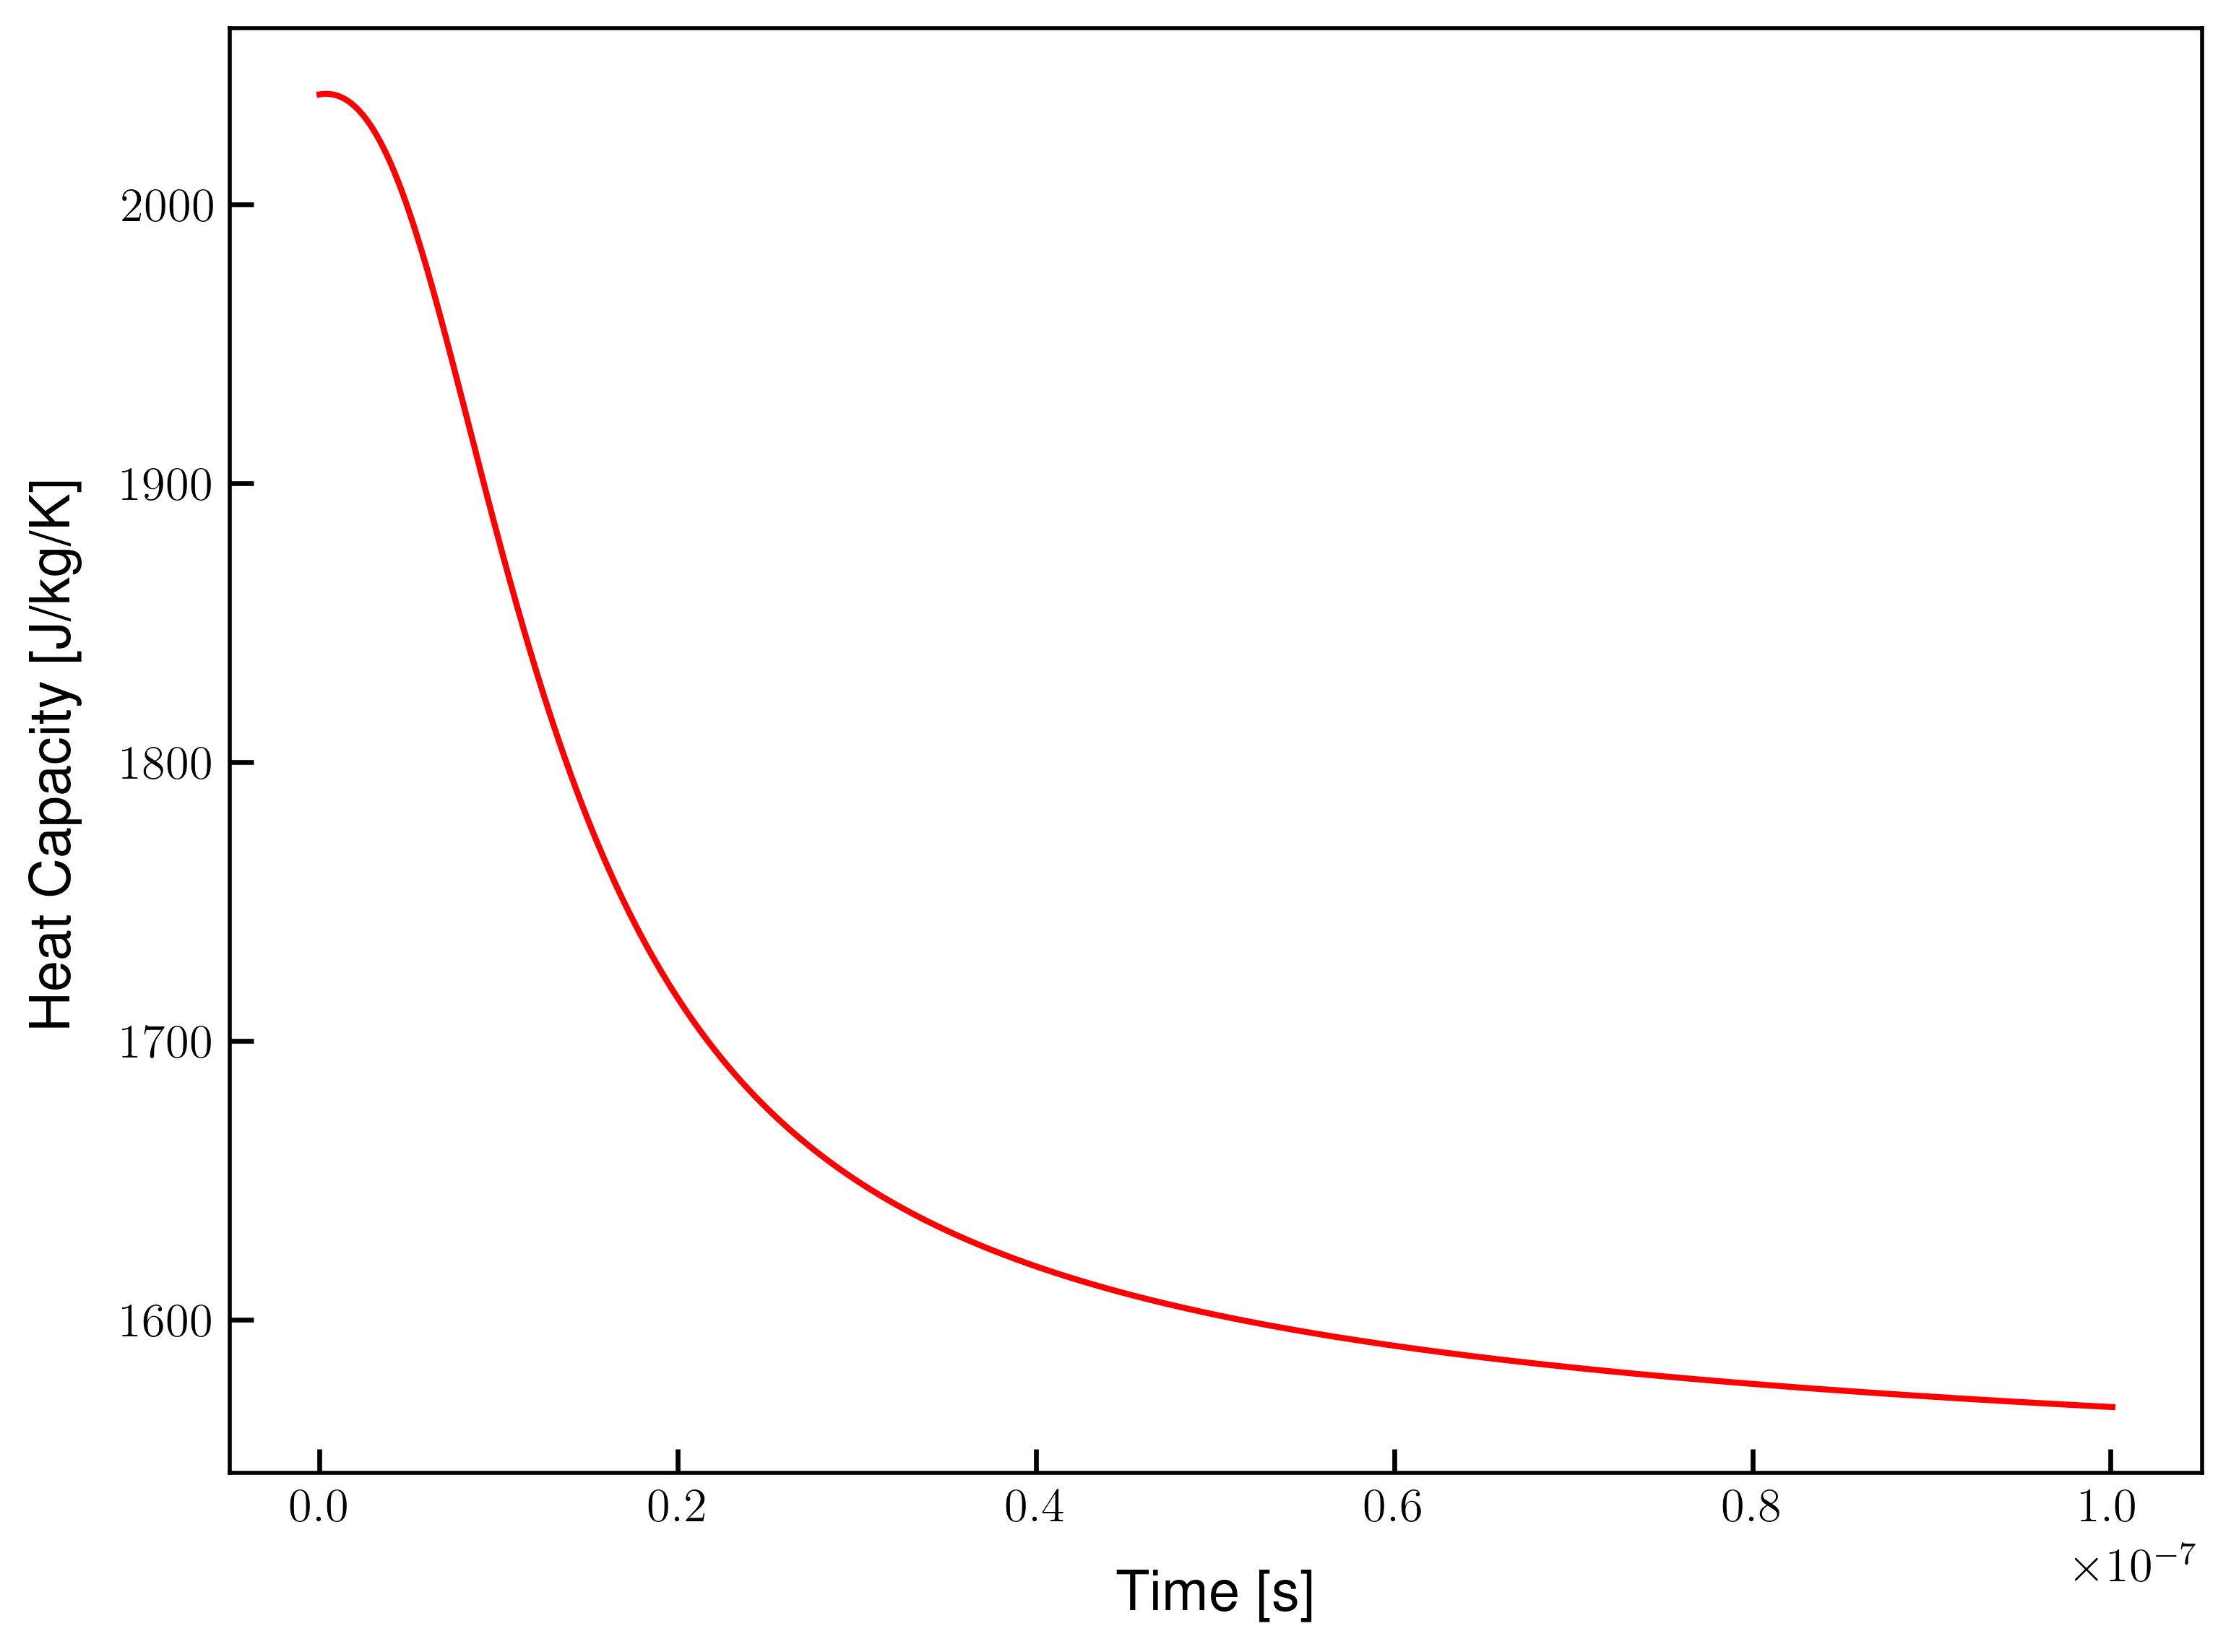

In [43]:
plt.figure()
plt.plot(time_reaction,Cps)
plt.ylabel('Heat Capacity [J/kg/K]')
plt.xlabel('Time [s]')